## Preprocessing pipeline

This notebook prepares **two model-ready datasets** for neighborhood-level crime prediction:

- **`base_dataset`**: cleaned **non-spatial** dataset (tabular predictors + targets)
- **`spatial_dataset`**: cleaned dataset with **spillover features based on exogenous predictors only** (Queen contiguity)

Key constraint: **no contemporaneous target-based spatial lag is included in exported model-ready datasets**.


## 1. Imports and configuration


In [ ]:
from __future__ import annotations

import logging
import re
from pathlib import Path
from typing import Iterable, Optional
from types import SimpleNamespace

import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PREPROC_DIR = Path("datasets/pre-processing")
PREPROC_DIR.mkdir(parents=True, exist_ok=True)

CFG = SimpleNamespace(
    # Inputs (intermediate artifacts live in datasets/pre-processing)
    tabular_csv=PREPROC_DIR / "cleaned_crime_nbh_2024.csv",
    spatial_gpkg=PREPROC_DIR / "merged_crime_nbh_2024.gpkg",
    spatial_layer=None,  # if None: pick first layer

    # If True: reuse merged GPKG produced in notebook 1.
    use_merged_gpkg_as_primary=True,

    # Merge keys
    tabular_key="gwb_code_10",
    spatial_key="gwb_code_10",

    # Raw columns
    raw_crime_col="GeregistreerdeMisdrijven_1",

    # Metric CRS for NL
    metric_crs="EPSG:28992",

    # Cleaning / filtering
    missing_col_threshold=0.15,

    # Spillover candidates (Queen contiguity lags)
    spillover_candidates=(
        "a_inw",
        "a_woning",
        "a_bedv",
        "a_pau",
        "a_opp_ha",
        "a_ll",  # created below as sum of education enrolment variables
    ),

    # Final exports (kept in datasets/ root)
    export_base_csv=Path("datasets/model_ready_base.csv"),
    export_spatial_csv=Path("datasets/model_ready_spatial.csv"),
    export_spatial_gpkg=Path("datasets/model_ready_spatial.gpkg"),
)


## Helper functions

Functions below keep the pipeline reproducible and defensible. Most cells below call these helpers and print compact audit outputs.


In [65]:
PLACEHOLDER_TOKENS = {".", "", " ", "  "}

# Return the list of layers in a GeoPackage file.
def list_gpkg_layers(path: Path):
    layers = pyogrio.list_layers(path)
    return [row[0] for row in layers]

# Load tabular data from a CSV file and log its shape.
def load_tabular(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    logger.info("Loaded tabular: %s rows, %s cols", len(df), df.shape[1])
    return df

# Load a layer from a GeoPackage file as a GeoDataFrame and log its shape.
def load_spatial(path: Path, layer: Optional[str] = None) -> gpd.GeoDataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    layer_names = list_gpkg_layers(path)
    if layer is None:
        layer = layer_names[0]
    if layer not in layer_names:
        raise ValueError(f"Layer '{layer}' not found. Available: {layer_names}")

    gdf = gpd.read_file(path, layer=layer, engine="pyogrio")
    logger.info("Loaded spatial layer '%s': %s rows, %s cols", layer, len(gdf), gdf.shape[1])
    return gdf

# Standardize a pandas Series by converting to string, stripping spaces, filling NAs, and upper-casing.
def standardize_key(s: pd.Series) -> pd.Series:
    return s.astype("string").fillna(pd.NA).str.strip().str.upper()

# Find and return duplicated values in key columns, logging their count.
def audit_duplicates(df: pd.DataFrame, key: str, label: str) -> pd.DataFrame:
    dup = df[key].duplicated(keep=False)
    n_dup = int(dup.sum())
    logger.info("%s duplicate keys in %s: %s", key, label, n_dup)
    if n_dup == 0:
        return pd.DataFrame(columns=[key, "count"])
    out = df.loc[dup, [key]].value_counts().reset_index(name="count")
    return out

# Merge tabular and spatial DataFrames using standardized keys with audit logging.
def merge_tabular_spatial(df_tab: pd.DataFrame, gdf_spatial: gpd.GeoDataFrame, tab_key: str, spatial_key: str):
    df_tab = df_tab.copy()
    gdf_spatial = gdf_spatial.copy()

    df_tab[tab_key] = standardize_key(df_tab[tab_key])
    gdf_spatial[spatial_key] = standardize_key(gdf_spatial[spatial_key])

    dup_tab = audit_duplicates(df_tab, tab_key, "tabular")
    dup_spa = audit_duplicates(gdf_spatial, spatial_key, "spatial")

    gdf = df_tab.merge(
        gdf_spatial[[spatial_key, "geometry"]],
        how="left",
        left_on=tab_key,
        right_on=spatial_key,
        validate="m:1",
    )
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=gdf_spatial.crs)

    n_total = len(df_tab)
    n_matched = int(gdf["geometry"].notna().sum())
    n_unmatched = n_total - n_matched
    pct = 100.0 * n_matched / n_total if n_total else 0.0

    unmatched_keys = (
        gdf.loc[gdf["geometry"].isna(), tab_key]
        .dropna()
        .astype("string")
        .unique()
        .tolist()
    )

    audit = {
        "rows_tabular": n_total,
        "rows_matched_geometry": n_matched,
        "rows_unmatched": n_unmatched,
        "pct_matched": pct,
        "dup_keys_tabular": int(df_tab[tab_key].duplicated().sum()),
        "dup_keys_spatial": int(gdf_spatial[spatial_key].duplicated().sum()),
        "rows_missing_geometry": int(gdf["geometry"].isna().sum()),
    }
    audit_df = pd.DataFrame([audit])

    logger.info("Merge audit: %s", audit)
    if unmatched_keys:
        logger.info("Unmatched keys (%d): %s", len(unmatched_keys), unmatched_keys)
    _ = unmatched_keys

    if not dup_tab.empty:
        logger.info("Duplicate keys in tabular: %s", dup_tab.to_dict(orient="records"))
    if not dup_spa.empty:
        logger.info("Duplicate keys in spatial: %s", dup_spa.to_dict(orient="records"))
    _ = (dup_tab, dup_spa)

    return gdf, audit_df

# Clean placeholder tokens in text columns and coerce numerics in a DataFrame, returning a summary.
def clean_placeholders_and_coerce_numeric(df: pd.DataFrame, id_cols: Iterable[str]):
    df = df.copy()
    id_cols = [c for c in id_cols if c in df.columns]

    before_dtypes = df.dtypes.astype(str)

    obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    for c in obj_cols:
        s = df[c].astype("string")
        s = s.str.replace(r"\s+", " ", regex=True)
        s = s.replace(list(PLACEHOLDER_TOKENS), pd.NA)
        df[c] = s

    for c in obj_cols:
        if c in id_cols:
            continue
        s = df[c]
        mask = s.str.match(r"^-?\d{1,3}(?:\.\d{3})*,\d+$", na=False) | s.str.match(r"^-?\d+,\d+$", na=False)
        if mask.any():
            df.loc[mask, c] = s.loc[mask].str.replace(".", "", regex=False).str.replace(",", ".", regex=False)

    after_dtypes = df.dtypes.astype(str).copy()
    for c in df.columns:
        if c in id_cols:
            continue
        if df[c].dtype.name in ("string", "object"):
            s0 = df[c]
            conv = pd.to_numeric(s0, errors="coerce")
            n_in = int(s0.notna().sum())
            n_out = int(conv.notna().sum())
            if n_in > 0 and (n_out / n_in) >= 0.9:
                df[c] = conv
        after_dtypes[c] = str(df[c].dtype)

    miss_pct = df.isna().mean().mul(100).round(2)
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype_before": before_dtypes.reindex(df.columns).values,
        "dtype_after": after_dtypes.reindex(df.columns).values,
        "pct_missing": miss_pct.values,
    }).sort_values("pct_missing", ascending=False)

    return df, summary

# Create target columns from raw columns in the DataFrame.
def create_targets(df: pd.DataFrame, crime_col: str):
    df = df.copy()
    df["crime_count"] = pd.to_numeric(df[crime_col], errors="coerce").astype(float)

    # Single target used downstream
    df["log_crime_count"] = np.log1p(np.clip(df["crime_count"], 0, None))

    return df

# Plot histograms for crime_count and log_crime_count target columns.
def plot_target_histograms(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(df["crime_count"].clip(lower=0).dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[0].set_title("crime_count")

    axes[1].hist(df["log_crime_count"].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[1].set_title("log_crime_count = log1p(count)")

    plt.tight_layout()
    plt.show()

# Drop columns with missing data above a threshold, except those protected; return new DataFrame and dropped cols.
def drop_high_missing_columns(df: pd.DataFrame, threshold: float, protect_cols: Iterable[str]):
    protect_cols = [c for c in protect_cols if c in df.columns]
    miss = df.isna().mean()
    drop_cols = [c for c in df.columns if (miss[c] > threshold and c not in protect_cols)]
    return df.drop(columns=drop_cols), drop_cols

# Impute missing numeric values with the median, excluding specified columns; returns imputed DataFrame and medians used.
def median_impute_numeric(df: pd.DataFrame, exclude_cols: Iterable[str]):
    df = df.copy()
    exclude_cols = [c for c in exclude_cols if c in df.columns]

    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    impute_cols = [c for c in num_cols if c not in exclude_cols]

    # Important: some numeric columns can be pandas nullable integers (Int64).
    # Median imputation can produce non-integer values, so we impute into float columns.
    df[impute_cols] = df[impute_cols].astype(float)

    medians = df[impute_cols].median(numeric_only=True)
    df[impute_cols] = df[impute_cols].fillna(medians)
    return df, medians

# Ensure a GeoDataFrame is in the desired metric coordinate reference system (CRS), reprojecting if necessary.
def ensure_metric_crs(gdf: gpd.GeoDataFrame, metric_crs: str):
    if gdf.crs is None:
        raise ValueError("Spatial data has no CRS; cannot reproject safely")
    if str(gdf.crs).upper() != metric_crs.upper():
        logger.info("Reprojecting from %s to %s", gdf.crs, metric_crs)
        gdf = gdf.to_crs(metric_crs)
    return gdf

# Compute centroid X/Y coordinates for each geometry as new columns in the GeoDataFrame.
def compute_centroid_metric(gdf: gpd.GeoDataFrame):
    gdf = gdf.copy()
    cent = gdf.geometry.centroid
    gdf["centroid_x"] = cent.x
    gdf["centroid_y"] = cent.y
    return gdf

# For each geo unit, build a series of its Queen-contiguous neighbors and a summary DataFrame of neighbor stats.
def build_queen_neighbors(gdf: gpd.GeoDataFrame, key: str):
    if key not in gdf.columns:
        raise KeyError(key)
    if gdf.geometry.isna().any():
        raise ValueError("Missing geometries present; cannot build weights")

    left = gdf[[key, "geometry"]].rename(columns={key: "k"})
    right = gdf[[key, "geometry"]].rename(columns={key: "n"})

    joined = gpd.sjoin(left, right, how="left", predicate="touches")
    joined = joined[joined["k"] != joined["n"]]

    neigh = joined.groupby("k")["n"].apply(list)
    neigh = neigh.reindex(gdf[key]).apply(lambda x: x if isinstance(x, list) else [])

    degrees = neigh.apply(len)
    summary = pd.DataFrame({
        "n_units": [len(gdf)],
        "avg_neighbors": [degrees.mean()],
        "min_neighbors": [degrees.min()],
        "max_neighbors": [degrees.max()],
        "pct_islands": [100.0 * (degrees.eq(0).mean())],
    })
    return neigh, summary

# Add spillover features with lag sum/mean for selected spatial spillover features in each neighborhood.
def add_spillover_lags(df: pd.DataFrame, key: str, neighbors: pd.Series, features: list[str], prefix: str = "queen", islands_fill=np.nan):
    df = df.copy().set_index(key, drop=False)

    for feat in features:
        vals = pd.to_numeric(df[feat], errors="coerce")
        lag_sum = []
        lag_mean = []
        for k, neigh_list in neighbors.items():
            if not neigh_list:
                lag_sum.append(islands_fill)
                lag_mean.append(islands_fill)
                continue
            neigh_vals = vals.reindex(neigh_list)
            lag_sum.append(neigh_vals.sum(skipna=True))
            lag_mean.append(neigh_vals.mean(skipna=True))
        df[f"{prefix}_lag_sum_{feat}"] = lag_sum
        df[f"{prefix}_lag_mean_{feat}"] = lag_mean

    return df.reset_index(drop=True)

# Produce a compact summary of basic descriptive statistics
def compact_describe(series: pd.Series):
    s = series.dropna()
    return pd.Series({
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p50": s.median(),
        "p95": s.quantile(0.95),
        "max": s.max(),
        "skew": s.skew(),
    })


## 2. Load raw tabular dataset


In [66]:
df_raw = load_tabular(CFG.tabular_csv)

INFO: Loaded tabular: 14494 rows, 124 cols


## 3. Load GeoPackage and inspect spatial layer


In [67]:
gdf_spatial_raw = load_spatial(CFG.spatial_gpkg, layer=CFG.spatial_layer)

INFO: Loaded spatial layer 'merged_crime_nbh_2024': 14494 rows, 134 cols


## 4. Standardize and verify merge keys


In [68]:
df_tab = df_raw.copy()
gdf_spatial = gdf_spatial_raw.copy()

df_tab[CFG.tabular_key] = standardize_key(df_tab[CFG.tabular_key])
gdf_spatial[CFG.spatial_key] = standardize_key(gdf_spatial[CFG.spatial_key])

## 5. Merge tabular and spatial data


In [69]:
# NOTE: Geometry was already merged in `1 - Merging Datasets.ipynb` into `CFG.spatial_gpkg`.
# By default we reuse that merged GeoPackage and only run a consistency audit here.

if CFG.use_merged_gpkg_as_primary and (CFG.raw_crime_col in gdf_spatial.columns):
    gdf_merged = gdf_spatial.copy()

    # Consistency audit vs tabular CSV (do NOT merge again)
    tab_k = df_tab[CFG.tabular_key]
    spa_k = gdf_merged[CFG.spatial_key]

    spa_key_set = set(spa_k.dropna().astype("string"))
    matched = tab_k.isin(spa_key_set)

    n_total = len(df_tab)
    n_matched = int(matched.sum())
    n_unmatched = int((~matched).sum())
    pct = 100.0 * n_matched / n_total if n_total else 0.0

    unmatched_keys = tab_k.loc[~matched].dropna().astype("string").unique().tolist()

    merge_audit = pd.DataFrame([
        {
            "rows_tabular": n_total,
            "rows_matched_geometry": int(gdf_merged["geometry"].notna().sum()),
            "rows_unmatched": n_unmatched,
            "pct_tabular_keys_present_in_gpkg": pct,
            "dup_keys_tabular": int(df_tab[CFG.tabular_key].duplicated().sum()),
            "dup_keys_spatial": int(gdf_merged[CFG.spatial_key].duplicated().sum()),
            "rows_missing_geometry": int(gdf_merged["geometry"].isna().sum()),
        }
    ])

    print(merge_audit.T)
    _ = unmatched_keys
else:
    # Fallback (only if you ever switch to a pure-geometry GPKG)
    gdf_merged, merge_audit = merge_tabular_spatial(
        df_tab=df_tab,
        gdf_spatial=gdf_spatial,
        tab_key=CFG.tabular_key,
        spatial_key=CFG.spatial_key,
    )

gdf_merged = ensure_metric_crs(gdf_merged, CFG.metric_crs)
gdf_merged = compute_centroid_metric(gdf_merged)


                                        0
rows_tabular                      14494.0
rows_matched_geometry             14494.0
rows_unmatched                        0.0
pct_tabular_keys_present_in_gpkg    100.0
dup_keys_tabular                      0.0
dup_keys_spatial                      0.0
rows_missing_geometry                 0.0


## 6. Clean numeric columns and placeholders


In [70]:
IDENTIFIER_COLS = [CFG.tabular_key, "regio", "gm_naam"]
SPATIAL_META_COLS = ["geometry", "centroid_x", "centroid_y"]

cleaned, missingness_summary = clean_placeholders_and_coerce_numeric(
    gdf_merged,
    # treat geometry as protected; centroid_x/y are numeric and will be handled as numerics
    id_cols=IDENTIFIER_COLS + ["geometry"],
)

# Save missingness table
missing_only = missingness_summary.loc[missingness_summary["pct_missing"] > 0].copy()
missing_only = missing_only.sort_values("pct_missing", ascending=False)
missing_only.to_csv(PREPROC_DIR / "missingness_by_column.csv", index=False)

gdf_clean = gpd.GeoDataFrame(cleaned, geometry="geometry", crs=gdf_merged.crs)


## 7. Create target variables


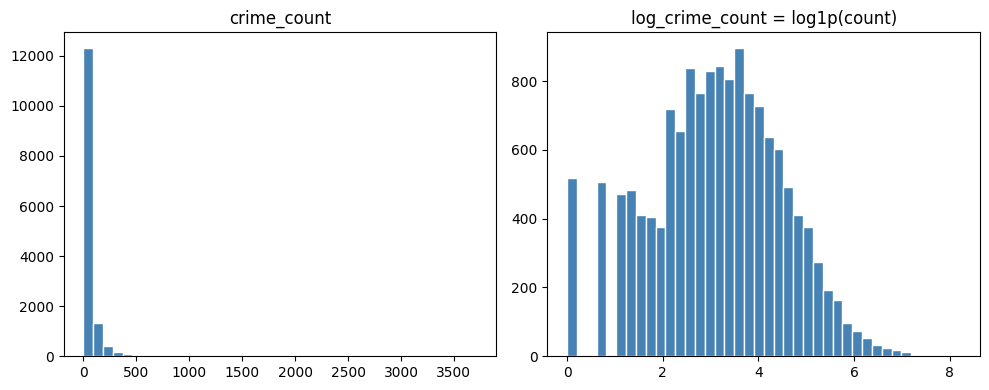

In [ ]:
# Create target
gdf_targets = create_targets(gdf_clean, crime_col=CFG.raw_crime_col)

# Create combined education enrolment feature (used as predictor + spillover input)
edu_cols = ["a_ons_po", "a_ons_vovavo", "a_ons_mbo", "a_ons_hbo", "a_ons_wo"]
for c in edu_cols:
    if c not in gdf_targets.columns:
        raise KeyError(f"Missing required column for a_ll: {c}")

gdf_targets["a_ll"] = (
    gdf_targets[edu_cols]
    .apply(pd.to_numeric, errors="coerce")
    .sum(axis=1, min_count=1)
)

plot_target_histograms(gdf_targets)


## 8. Filter rows and columns

All neighbourhoods are kept (including `a_inw = 0`).


In [ ]:
full_gdf_for_inspection = gdf_targets.copy()

model_gdf = gdf_targets.copy()

# Single modeling target
TARGET_COLS = ["log_crime_count"]

# Additional non-feature columns to protect from dropping
NON_FEATURE_COLS = ["crime_count"]

PROTECT_COLS = IDENTIFIER_COLS + SPATIAL_META_COLS + TARGET_COLS + NON_FEATURE_COLS

filtered_gdf, dropped_cols = drop_high_missing_columns(model_gdf, CFG.missing_col_threshold, protect_cols=PROTECT_COLS)


## 9. Spatial weights and spillover feature engineering

**Important (leakage control):** this notebook does **not** impute missing values for modeling. All imputation is performed **within-fold** inside the scikit-learn model pipelines (see modeling notebooks), so that medians are learned from training folds only.

Here we only compute spatial adjacency (Queen contiguity) and construct spillover lag features. For neighborhoods with **no neighbors** (“islands”), spillover lag features remain `NaN` and are imputed within-fold during model training.


In [73]:
# No pre-model imputation here (handled within-fold during modeling).
geo_ready = filtered_gdf.dropna(subset=["geometry"]).copy()
geo_ready = ensure_metric_crs(geo_ready, CFG.metric_crs)

neighbors, w_summary = build_queen_neighbors(geo_ready, key=CFG.tabular_key)


## 9b. Spillover features (EXOGENOUS predictors only)

Spillover features are constructed only from a small set of exogenous predictors.


In [74]:
available = set(geo_ready.columns)
spillover_features = [c for c in CFG.spillover_candidates if c in available]
missing_spill = [c for c in CFG.spillover_candidates if c not in available]

if missing_spill:
    raise ValueError(f"Missing required spillover predictors in dataset: {missing_spill}")

spatial_gdf = add_spillover_lags(
    df=geo_ready,
    key=CFG.tabular_key,
    neighbors=neighbors,
    features=spillover_features,
    prefix="queen",
    islands_fill=np.nan,
)

TARGET_LAG_LIKE = [c for c in spatial_gdf.columns if re.search(r"lag_.*crime|crime.*lag|spillover_lag", c, flags=re.IGNORECASE)]
if TARGET_LAG_LIKE:
    _ = TARGET_LAG_LIKE


## 10. Export model-ready datasets

Exports:
- `base_dataset` (**non-spatial**) → CSV
- `spatial_dataset` (**with exogenous spillovers**) → CSV and GeoPackage

Exported datasets exclude any target-lag-like features.


In [75]:
# Base (tabular) model-ready dataset: drop geometry, keep NaNs (imputed within-fold during modeling)
base_dataset = filtered_gdf.copy()
base_dataset = pd.DataFrame(base_dataset.drop(columns=["geometry"], errors="ignore"))

# Spatial model-ready dataset: keep geometry + spillover lags
spatial_dataset = spatial_gdf.copy()

# Ensure exported datasets never contain contemporaneous target-based lags
if TARGET_LAG_LIKE:
    base_dataset = base_dataset.drop(columns=[c for c in TARGET_LAG_LIKE if c in base_dataset.columns], errors="ignore")
    spatial_dataset = spatial_dataset.drop(columns=[c for c in TARGET_LAG_LIKE if c in spatial_dataset.columns], errors="ignore")

# GeoPackage supports only ONE geometry column
geom_cols = [c for c in spatial_dataset.columns if str(spatial_dataset.dtypes[c]) == "geometry"]
if len(geom_cols) > 1:
    extra = [c for c in geom_cols if c != "geometry"]
    for c in extra:
        spatial_dataset[c] = spatial_dataset[c].to_wkt()

spatial_dataset = spatial_dataset.set_geometry("geometry")

# Export final datasets
CFG.export_base_csv.parent.mkdir(parents=True, exist_ok=True)
base_dataset.to_csv(CFG.export_base_csv, index=False)

spatial_dataset.to_file(CFG.export_spatial_gpkg, layer="model_ready_spatial", driver="GPKG")
pd.DataFrame(spatial_dataset.drop(columns=["geometry"], errors="ignore")).to_csv(CFG.export_spatial_csv, index=False)


INFO: Created 14,494 records


## 11. Pre-model audit summary


In [76]:
audit = {
    "starting_row_count": len(df_raw),
    "final_row_count": len(model_gdf),
    "starting_column_count": df_raw.shape[1],
    "final_base_columns": len(base_dataset.columns),
    "final_spatial_columns": len(spatial_dataset.columns),
    "n_columns_dropped_missingness": len(dropped_cols),
    "selected_spillover_variables": spillover_features,
    "avg_neighbors": float(w_summary["avg_neighbors"].iloc[0]),
    "min_neighbors": int(w_summary["min_neighbors"].iloc[0]),
    "max_neighbors": int(w_summary["max_neighbors"].iloc[0]),
    "pct_islands": float(w_summary["pct_islands"].iloc[0]),
    "exported_files": [str(CFG.export_base_csv), str(CFG.export_spatial_csv), str(CFG.export_spatial_gpkg)],
}

audit_df = pd.DataFrame([audit])
audit_df.to_csv(PREPROC_DIR / "preprocessing_audit_summary.csv", index=False)

print(audit_df)

   starting_row_count  final_row_count  starting_column_count  final_base_columns  final_spatial_columns  n_columns_dropped_missingness  \
0               14494            14494                    124                 102                    115                             36   

                       selected_spillover_variables  avg_neighbors  min_neighbors  max_neighbors  pct_islands  \
0  [a_inw, a_woning, a_bedv, a_pau, a_opp_ha, a_ll]       5.731199              0             36     0.068994   

                                      exported_files  
0  [datasets/model_ready_base.csv, datasets/model...  


## Summary

- **Target transformation**: crime counts are heavy-tailed. Using `log1p` stabilizes variance and reduces the influence of extreme outliers.
- **No population-based row exclusion**: neighbourhoods with `a_inw = 0` are retained.
- **Exogenous spillover features (instead of target lag)**: spatial context is captured using neighbour summaries of selected **predictors**. Contemporaneous **target** lags are avoided.
- **Leakage-safe missingness handling**: missing values (including spillover features undefined for islands) are imputed **within each training fold** in the modeling pipelines.


## Final exported datasets

- **Base (non-spatial) modeling dataset**: `datasets/model_ready_base.csv`
  - contains: cleaned non-spatial predictors + the target
  - excludes: geometry

- **Spatial modeling dataset**: `datasets/model_ready_spatial.csv` and `datasets/model_ready_spatial.gpkg`
  - contains: the same cleaned predictors + the target + exogenous Queen-contiguity spillover features
  - includes: geometry in the GPKG export

- **Target used for modeling (both datasets)**: `log_crime_count = log1p(crime_count)`

- **Spillover variables included** (exogenous only; generated in section 9b):
  - `spillover_features` (printed in the pipeline output)
  - for each selected feature \(X\): `queen_lag_mean_X` and `queen_lag_sum_X`

- **No contemporaneous target lag is exported**.
